<a href="https://colab.research.google.com/github/Zukap/TalentoTech/blob/main/RedNeuronalDeRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Cargar el conunto de datos
housing = fetch_california_housing()

In [ ]:
# Crear conjuntos de datos de entrenamiento, validacion y prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [ ]:

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('X_valid:', X_valid.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('y_valid:', y_valid.shape)

X_train: (11610, 8)
X_test: (5160, 8)
X_valid: (3870, 8)
y_train: (11610,)
y_test: (5160,)
y_valid: (3870,)


In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_valid = scaler.transform(X_valid)

In [ ]:
# Compilar el modelo:
model = keras.models.Sequential([keras.layers.Dense(30, activation='relu', input_shape=X_train.shape[1:]), keras.layers.Dense(1)])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.0826 - mean_absolute_percentage_error: 39.8722 - root_mean_squared_error: 1.0405 - val_loss: 0.6771 - val_mean_absolute_percentage_error: 34.5950 - val_root_mean_squared_error: 0.8228
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5924 - mean_absolute_percentage_error: 31.4440 - root_mean_squared_error: 0.7697 - val_loss: 0.5103 - val_mean_absolute_percentage_error: 29.3564 - val_root_mean_squared_error: 0.7144
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4703 - mean_absolute_percentage_error: 27.9865 - root_mean_squared_error: 0.6857 - val_loss: 0.4490 - val_mean_absolute_percentage_error: 27.5049 - val_root_mean_squared_error: 0.6701
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4282 - mean_absolute_percentage_error: 26.7147 - root_mean_squared_error: 0.6543 - val_loss: 0.4287 - val_mean_absolute_percentage_error: 27.3479 - val_root_mean_squared_error: 0.6547
Epoch 5/20
363/3

<Axes: >

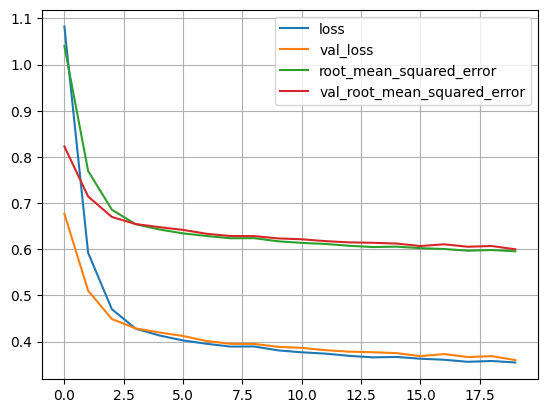

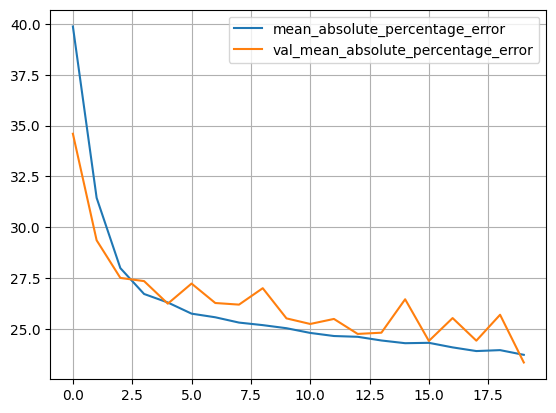

In [ ]:
# Graficar el historial de entrenamiento
# Compilar el modelo antes de entrenar
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['root_mean_squared_error', 'mean_absolute_percentage_error'])

# Entrenar el modelo para obtener el objeto history
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

dfHistory = pd.DataFrame(history.history)
dfHistory[['loss', 'val_loss', 'root_mean_squared_error', 'val_root_mean_squared_error']].plot(grid=True)

dfHistory[['mean_absolute_percentage_error', 'val_mean_absolute_percentage_error']].plot(grid=True)

In [ ]:
# Evaluar el modelo en el conjunto de entrenamiento
loss, RMSE, MAPE = model.evaluate(X_train, y_train)
print("Evaluar el modelo en el conjunto de entrenamiento")
print("loss valid:", loss)
print("root_mean_squared_error valid:", RMSE)
print("mean_absolute_percentage_error valid:", MAPE)

loss, RMS, MAPE = model.evaluate(X_valid, y_valid)
print("Evaluar el modelo en el conjunto de entrenamiento")
print("loss valid:", loss)
print("root_mean_squared_error valid:", RMSE)
print("mean_absolute_percentage_error valid:", MAPE)

loss, RMS, MAPE = model.evaluate(X_test, y_test)
print("Evaluar el modelo en el conjunto de entrenamiento")
print("loss valid:", loss)
print("root_mean_squared_error valid:", RMSE)
print("mean_absolute_percentage_error valid:", MAPE)

363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3510 - mean_absolute_percentage_error: 22.4949 - root_mean_squared_error: 0.5925
Evaluar el modelo en el conjunto de entrenamiento
loss valid: 0.3510444760322571
root_mean_squared_error valid: 0.5924900770187378
mean_absolute_percentage_error valid: 22.4948787689209
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3600 - mean_absolute_percentage_error: 23.3458 - root_mean_squared_error: 0.6000
Evaluar el modelo en el conjunto de entrenamiento
loss valid: 0.3600095808506012
root_mean_squared_error valid: 0.5924900770187378
mean_absolute_percentage_error valid: 23.345813751220703
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3451 - mean_absolute_percentage_error: 22.6535 - root_mean_squared_error: 0.5874
Evaluar el modelo en el conjunto de entrenamiento
loss valid: 0.3450613021850586
root_mean_squared_error valid: 0.5924900770187378
mean_absolute_percentage_error valid: 22.653478622436523
